# Step 2 P-v Map
Render physics-informed and baseline UTS maps from `step2_pv_map_data.csv`.

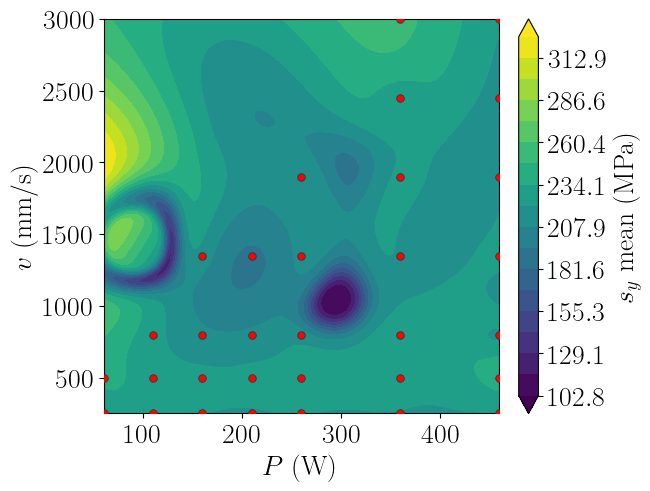

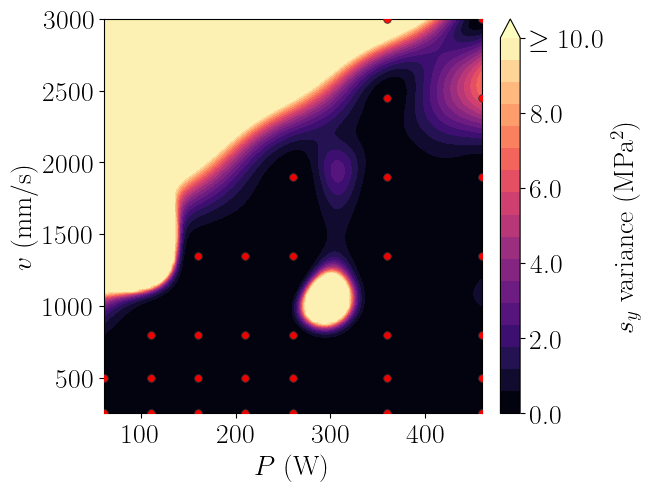

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# Global font size control
FONT_SIZE = 20

# LaTeX-style serif fonts (requires a LaTeX install).
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "axes.unicode_minus": False,
    "font.size": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,
    "legend.fontsize": FONT_SIZE,
})

data_path = "../step2_pv_map_data.csv"
df = pd.read_csv(data_path)

def pivot_grid(frame, value_col):
    grid = frame.pivot(index="v", columns="P", values=value_col)
    grid = grid.sort_index().sort_index(axis=1)
    return grid

mean_grid = pivot_grid(df, "physics_mean")
var_grid = pivot_grid(df, "physics_var")

p_vals = mean_grid.columns.values
v_vals = mean_grid.index.values
p_mesh, v_mesh = np.meshgrid(p_vals, v_vals)

# Raw row locations for scatter (match Step2 plot)
raw = pd.read_excel("../../data/AlSi10Mg PSP feature table.xlsx", header=None)
rows = raw.iloc[4:4 + 32].copy()
scatter_p = pd.to_numeric(rows.iloc[:, 2], errors="coerce").to_numpy()
scatter_v = pd.to_numeric(rows.iloc[:, 3], errors="coerce").to_numpy()

variance_clip = 10.0
mean_levels = np.linspace(float(mean_grid.values.min()), float(mean_grid.values.max()), 18)
var_levels = np.linspace(0.0, variance_clip, 18)

marker_face = "#ff0000"
marker_edge = "#333333"

# Mean figure
fig_mean, ax_mean = plt.subplots(1, 1, figsize=(6.4, 4.8), constrained_layout=True)
mean_cf = ax_mean.contourf(
    p_mesh,
    v_mesh,
    mean_grid.values,
    levels=mean_levels,
    cmap="viridis",
    extend="both",
)
ax_mean.scatter(
    scatter_p,
    scatter_v,
    s=30,
    c=marker_face,
    edgecolors=marker_edge,
    linewidths=0.6,
    alpha=0.95,
    zorder=3,
)
ax_mean.set_xlabel(r"$P$ (W)")
ax_mean.set_ylabel(r"$v$ (mm/s)")
cbar_mean = fig_mean.colorbar(mean_cf, ax=ax_mean)
cbar_mean.set_label(r"$s_y$ mean (MPa)")
ax_mean.set_xlim(float(p_vals.min()), float(p_vals.max()))
ax_mean.set_ylim(float(v_vals.min()), float(v_vals.max()))
fig_mean.savefig("step2_pv_mean_replot.png", dpi=300, bbox_inches="tight")

# Variance figure
fig_var, ax_var = plt.subplots(1, 1, figsize=(6.4, 4.8), constrained_layout=True)
var_cf = ax_var.contourf(
    p_mesh,
    v_mesh,
    np.minimum(var_grid.values, variance_clip),
    levels=var_levels,
    cmap="magma",
    extend="max",
)
ax_var.scatter(
    scatter_p,
    scatter_v,
    s=30,
    c=marker_face,
    edgecolors=marker_edge,
    linewidths=0.6,
    alpha=0.95,
    zorder=3,
)
ax_var.set_xlabel(r"$P$ (W)")
ax_var.set_ylabel(r"$v$ (mm/s)")
cbar_var = fig_var.colorbar(var_cf, ax=ax_var)
ticks = np.linspace(0.0, variance_clip, 6)
cbar_var.set_ticks(ticks)
tick_labels = [f"{tick:.1f}" for tick in ticks]
tick_labels[-1] = rf"$\geq {variance_clip:.1f}$"
cbar_var.set_ticklabels(tick_labels)
cbar_var.set_label(r"$s_y$ variance (MPa$^2$)")
ax_var.set_xlim(float(p_vals.min()), float(p_vals.max()))
ax_var.set_ylim(float(v_vals.min()), float(v_vals.max()))
fig_var.savefig("step2_pv_var_replot.png", dpi=300, bbox_inches="tight")

plt.show()

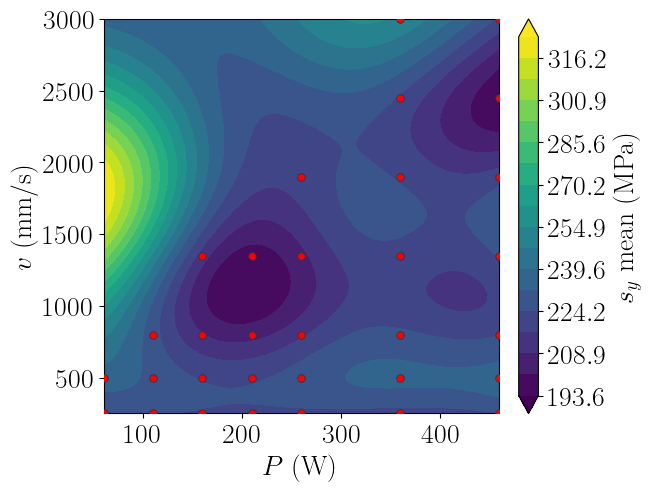

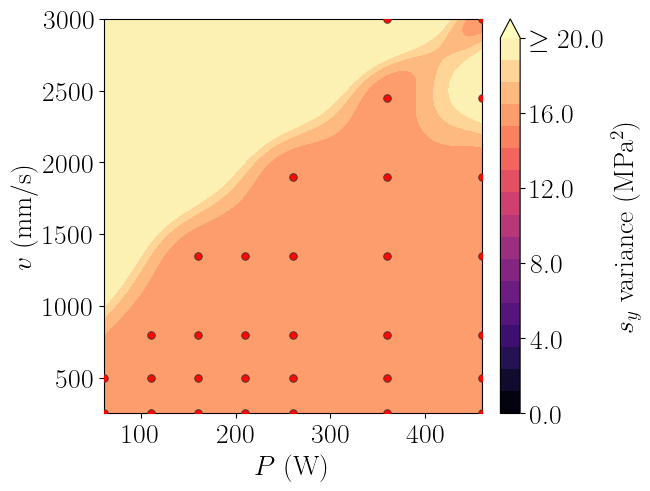

In [2]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# Global font size control
FONT_SIZE = 20

# LaTeX-style serif fonts (requires a LaTeX install).
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "axes.unicode_minus": False,
    "font.size": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,
    "legend.fontsize": FONT_SIZE,
})

data_path = "../step2_pv_map_data.csv"
df = pd.read_csv(data_path)

def pivot_grid(frame, value_col):
    grid = frame.pivot(index="v", columns="P", values=value_col)
    grid = grid.sort_index().sort_index(axis=1)
    return grid

mean_grid = pivot_grid(df, "baseline_mean")
var_grid = pivot_grid(df, "baseline_var")

p_vals = mean_grid.columns.values
v_vals = mean_grid.index.values
p_mesh, v_mesh = np.meshgrid(p_vals, v_vals)

# Raw row locations for scatter (match Step2 plot)
raw = pd.read_excel("../../data/AlSi10Mg PSP feature table.xlsx", header=None)
rows = raw.iloc[4:4 + 32].copy()
scatter_p = pd.to_numeric(rows.iloc[:, 2], errors="coerce").to_numpy()
scatter_v = pd.to_numeric(rows.iloc[:, 3], errors="coerce").to_numpy()

variance_clip = 20.0
mean_levels = np.linspace(float(mean_grid.values.min()), float(mean_grid.values.max()), 18)
var_levels = np.linspace(0.0, variance_clip, 18)

marker_face = "#ff0000"
marker_edge = "#333333"

# Mean figure
fig_mean, ax_mean = plt.subplots(1, 1, figsize=(6.4, 4.8), constrained_layout=True)
mean_cf = ax_mean.contourf(
    p_mesh,
    v_mesh,
    mean_grid.values,
    levels=mean_levels,
    cmap="viridis",
    extend="both",
)
ax_mean.scatter(
    scatter_p,
    scatter_v,
    s=30,
    c=marker_face,
    edgecolors=marker_edge,
    linewidths=0.6,
    alpha=0.95,
    zorder=3,
)
ax_mean.set_xlabel(r"$P$ (W)")
ax_mean.set_ylabel(r"$v$ (mm/s)")
cbar_mean = fig_mean.colorbar(mean_cf, ax=ax_mean)
cbar_mean.set_label(r"$s_y$ mean (MPa)")
ax_mean.set_xlim(float(p_vals.min()), float(p_vals.max()))
ax_mean.set_ylim(float(v_vals.min()), float(v_vals.max()))
fig_mean.savefig("step2_pv_mean_replot1.png", dpi=300, bbox_inches="tight")

# Variance figure
fig_var, ax_var = plt.subplots(1, 1, figsize=(6.4, 4.8), constrained_layout=True)
var_cf = ax_var.contourf(
    p_mesh,
    v_mesh,
    np.minimum(var_grid.values, variance_clip),
    levels=var_levels,
    cmap="magma",
    extend="max",
)
ax_var.scatter(
    scatter_p,
    scatter_v,
    s=30,
    c=marker_face,
    edgecolors=marker_edge,
    linewidths=0.6,
    alpha=0.95,
    zorder=3,
)
ax_var.set_xlabel(r"$P$ (W)")
ax_var.set_ylabel(r"$v$ (mm/s)")
cbar_var = fig_var.colorbar(var_cf, ax=ax_var)
ticks = np.linspace(0.0, variance_clip, 6)
cbar_var.set_ticks(ticks)
tick_labels = [f"{tick:.1f}" for tick in ticks]
tick_labels[-1] = rf"$\geq {variance_clip:.1f}$"
cbar_var.set_ticklabels(tick_labels)
cbar_var.set_label(r"$s_y$ variance (MPa$^2$)")
ax_var.set_xlim(float(p_vals.min()), float(p_vals.max()))
ax_var.set_ylim(float(v_vals.min()), float(v_vals.max()))
fig_var.savefig("step2_pv_var_replot1.png", dpi=300, bbox_inches="tight")

plt.show()

# Step 3 Convergence
Render convergence curves from `step3_convergence_data.csv` with the same font and style.

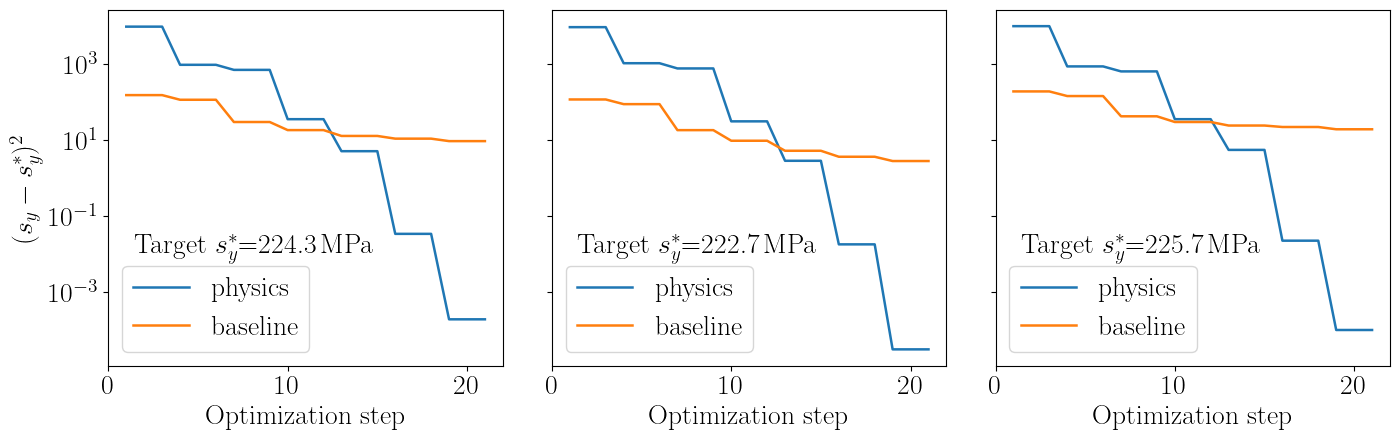

In [3]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# Global font size control (keep consistent with previous figures)
FONT_SIZE = 20

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "axes.unicode_minus": False,
    "font.size": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,
    "legend.fontsize": FONT_SIZE,
})

data_path = "../step3_convergence_data.csv"
df = pd.read_csv(data_path)

# Plot specific groups in one row
groups_to_plot = [21, 13, 30]
df = df[df["group_id"].isin(groups_to_plot)].copy()

group_ids = sorted(df["group_id"].unique().tolist())
if not group_ids:
    raise ValueError("No groups available after filtering. Check groups_to_plot.")

group_target_map = (
    df.drop_duplicates(["group_id", "target_UTS"]).set_index("group_id")["target_UTS"].to_dict()
)

ncols = len(group_ids)
nrows = 1
fig, axes = plt.subplots(nrows, ncols, figsize=(4.8 * ncols, 4.8), sharey=True)
axes = np.atleast_1d(axes).ravel()

for i, gid in enumerate(group_ids):
    ax = axes[i]
    sub = df[df["group_id"] == gid]
    phys = sub[sub["model"] == "physics"].sort_values("eval_idx")
    base = sub[sub["model"] == "baseline"].sort_values("eval_idx")
    ax.plot(phys["eval_idx"], phys["loss"], color="tab:blue", linewidth=1.8, label="physics")
    ax.plot(base["eval_idx"], base["loss"], color="tab:orange", linewidth=1.8, label="baseline")
    ax.set_yscale("log")
    ax.set_xlabel("Optimization step")
    ax.text(
        0.67,
        0.37,
        rf"Target $s^*_y$={group_target_map[gid]:.1f}\,MPa",
        transform=ax.transAxes,
        ha="right",
        va="top",
)
    ax.legend(loc="lower left", fontsize=FONT_SIZE)

axes[0].set_ylabel(r"($s_y - s_y^*)^2$")
fig.tight_layout()
fig.savefig("step3_convergence_replot.png", dpi=300, bbox_inches="tight")

plt.show()

# Step 4 Ablation Metrics
Bar charts for ablation MAE/RMSE (exclude expectation checks).

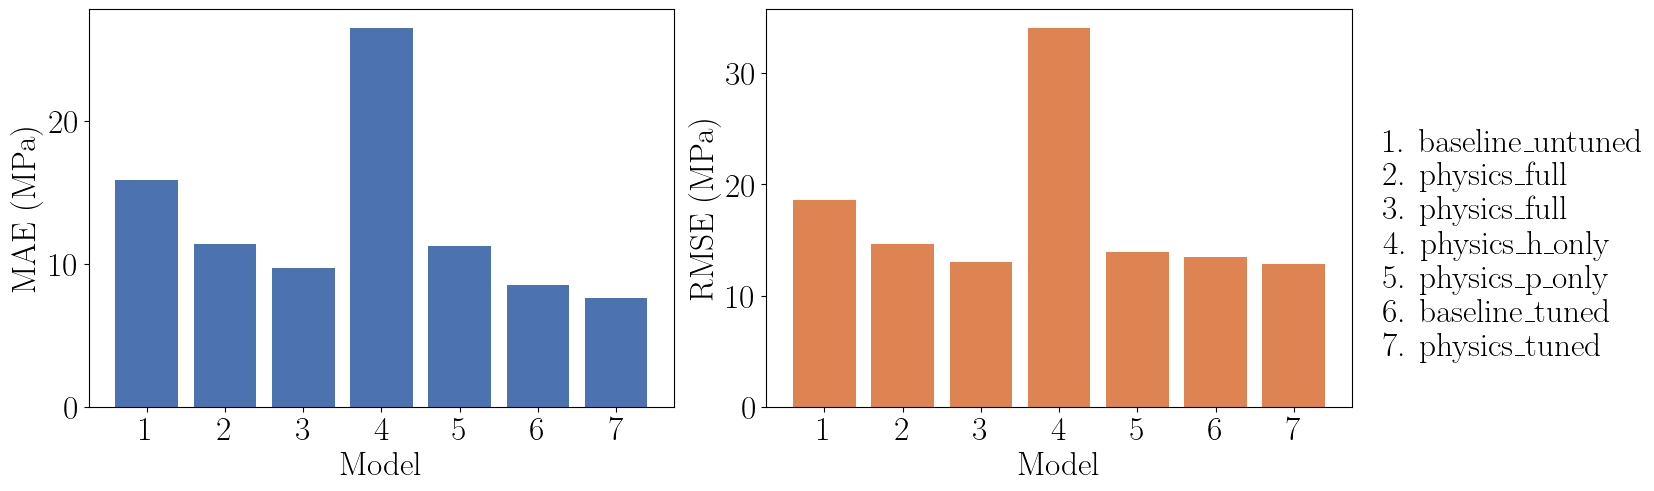

In [7]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# Global font size control (keep consistent with previous figures)
FONT_SIZE = 24

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "axes.unicode_minus": False,
    "font.size": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,
    "legend.fontsize": FONT_SIZE,
})

data_path = "../step4_ablation_metrics.csv"
df_raw = pd.read_csv(data_path)

# Row order includes header (row 1 is header, row 2 is first data row)
row_order_1b = [3, 2, 8, 6, 7, 4, 5]
row_order_0b = [idx - 2 for idx in row_order_1b]
if any(idx < 0 for idx in row_order_0b):
    raise ValueError("Row order includes header, so row numbers must be >= 2.")
selected = df_raw.iloc[row_order_0b].copy()

# Exclude expectation_check after selecting by row order
df = selected[selected["scenario"] != "expectation_check"].reset_index(drop=True)

# Numeric x-axis labels only
x = np.arange(1, len(df) + 1)
x_labels = [str(i) for i in x]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), constrained_layout=True)

axes[0].bar(x, df["test_mae"].to_numpy(dtype=float), color="#4C72B0")
axes[0].set_xticks(x, x_labels)
axes[0].set_xlabel(r"Model")
axes[0].set_ylabel(r"MAE (MPa)")

axes[1].bar(x, df["test_rmse"].to_numpy(dtype=float), color="#DD8452")
axes[1].set_xticks(x, x_labels)
axes[1].set_xlabel(r"Model")
axes[1].set_ylabel(r"RMSE (MPa)")

# Side legend with model descriptions
legend_lines = [f"{i + 1}. {m}" for i, m in enumerate(df["model"].tolist())]
legend_text = "\n".join(legend_lines)
fig.text(1.02, 0.5, legend_text, va="center", ha="left")

fig.savefig("step4_ablation_metrics_replot.png", dpi=300, bbox_inches="tight")
plt.show()